# RetinaEdge-DR — Notebook 02 · Calibration & ONNX export

From a (tiny, synthetic) trained grader to a **verified, calibrated export artefact**:

1. retrain the Notebook-01 model (self-contained, ~1 min on CPU)
2. **temperature scaling** of the cumulative logits (LBFGS on validation NLL) + reliability
   diagrams and ECE before/after
3. export the **contract graph** — `float32 (1,3,H,W)` → `float32 (1,5)` calibrated probs —
   to ONNX (opset 17, dynamic batch)
4. verify **runtime parity** vs PyTorch (`atol 1e-3`), micro-benchmark latency, and preview
   int8 dynamic quantization

Contract: `docs/INTERFACES.md` v1.0 · docs: `docs/TRAINING.md` §5, `docs/EXPORT_DEPLOY.md`.

> ⚠️ Research/educational — **not** a medical device.

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import numpy as np
import timm
import torch
from torch import nn

REPO = Path.cwd()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
for _p in (REPO, REPO / "src"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

from retinaedge.models.ordinal_ops import ordinal_probs
from retinaedge.utils.seed import seed_everything

ART = REPO / "artifacts" / "notebooks"
ART.mkdir(parents=True, exist_ok=True)
IMG_SIZE, SEED = 64, 0
CLASS_DIST = np.array([0.45, 0.20, 0.15, 0.10, 0.10])
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)
print("artifacts ->", ART)

/home/z/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


artifacts -> /home/z/my-project/retinaedge-dr/artifacts/notebooks


## 1 · Rebuild + quick train (self-contained)

Condensed Notebook-01 recipe: procedural synthetic data → `TinyDrNet` (contract-shaped) →
CORAL + referable BCE, 2 epochs. We also define the 15-bin ECE helper here so the whole
notebook is runnable top-to-bottom on its own.

In [2]:
def make_synthetic_split(n: int, seed: int, split_offset: int) -> tuple[np.ndarray, np.ndarray]:
    """Procedural fundus-like discs; severity ~ brightness + exudate blob count."""
    rng = np.random.default_rng(seed + split_offset)
    y = rng.choice(5, size=n, p=CLASS_DIST)
    size = IMG_SIZE
    yy, xx = np.mgrid[0:size, 0:size]
    cx = cy = (size - 1) / 2
    radius = size * 0.42
    disc = ((xx - cx) ** 2 + (yy - cy) ** 2) <= radius**2
    imgs = np.zeros((n, 3, size, size), dtype=np.float32)
    for i, grade in enumerate(y):
        img = rng.normal(0.22 + 0.05 * grade, 0.02, size=(3, size, size))
        img[:, ~disc] = 0.02
        img[0][disc] += 0.10 + 0.03 * grade
        for _ in range(int(grade)):
            ang = rng.uniform(0, 2 * np.pi)
            dist = rng.uniform(0, radius * 0.95)
            bx, by = cx + dist * np.cos(ang), cy + dist * np.sin(ang)
            glow = np.exp(-(((xx - bx) ** 2 + (yy - by) ** 2) / (2 * 2.0**2)))
            img += glow[None] * 0.35
        img += rng.normal(0.0, 0.02, size=img.shape)
        imgs[i] = (img - IMAGENET_MEAN[:, None, None]) / IMAGENET_STD[:, None, None]
    return imgs, y.astype(np.int64)


def ece_binary(conf: np.ndarray, correct: np.ndarray, n_bins: int = 15) -> float:
    """15-bin expected calibration error for a binary confidence score."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    total = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf >= lo) & (conf <= hi) if lo == 0 else (conf > lo) & (conf <= hi)
        if m.any():
            total += float(m.mean()) * abs(float(correct[m].mean()) - float(conf[m].mean()))
    return total


class TinyDrNet(nn.Module):
    """Contract-shaped stand-in for DrNet: ordinal (B,4) + referable (B,1) heads."""

    def __init__(self, backbone: str = "mobilenetv3_small_100", dropout: float = 0.1) -> None:
        super().__init__()
        self.backbone = timm.create_model(
            backbone, pretrained=False, num_classes=0, global_pool="avg"
        )
        with torch.no_grad():
            self.embed_dim = int(self.backbone(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)).shape[-1])
        self.drop = nn.Dropout(dropout)
        self.ordinal_head = nn.Linear(self.embed_dim, 4)
        self.refer_head = nn.Linear(self.embed_dim, 1)

    def forward(self, imgs: torch.Tensor) -> dict[str, torch.Tensor]:
        feats = self.drop(self.backbone(imgs))
        return {"ordinal_logits": self.ordinal_head(feats), "refer_logits": self.refer_head(feats)}


seed_everything(SEED)
x_tr, y_tr = make_synthetic_split(240, SEED, 0)
x_va, y_va = make_synthetic_split(80, SEED, 1)
model = TinyDrNet()
opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=0.01)
for epoch in range(2):
    model.train()
    running = 0.0
    for i in range(0, len(x_tr), 32):
        xb = torch.from_numpy(x_tr[i : i + 32])
        yb = torch.from_numpy(y_tr[i : i + 32])
        out = model(xb)
        levels = (yb[:, None] > torch.arange(4)[None, :]).float()
        l_ord = nn.functional.binary_cross_entropy_with_logits(out["ordinal_logits"], levels)
        l_ref = nn.functional.binary_cross_entropy_with_logits(
            out["refer_logits"].squeeze(-1), (yb >= 2).float()
        )
        loss = l_ord + 0.3 * l_ref
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        running += float(loss) * len(xb)
    print(f"epoch {epoch + 1}: train loss {running / len(x_tr):.4f}")


@torch.no_grad()
def collect_logits(m: nn.Module, xs: np.ndarray) -> torch.Tensor:
    """Validation ordinal logits (n,4) with the model in eval mode."""
    m.eval()
    return torch.cat(
        [m(torch.from_numpy(xs[i : i + 64]))["ordinal_logits"] for i in range(0, len(xs), 64)]
    )


val_logits = collect_logits(model, x_va)
val_targets = torch.from_numpy(y_va)
print("val logits:", tuple(val_logits.shape))

/tmp/ipykernel_6528/220015977.py:77: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  running += float(loss) * len(xb)


epoch 1: train loss 0.4785


epoch 2: train loss 0.1948


val logits: (80, 4)


## 2 · Temperature scaling

Divide the 4 cumulative logits by a scalar `T > 0` — this leaves the argmax and the ordinal
ranking untouched but reshapes confidence. `T` is fitted by minimising NLL on the validation
set (single-parameter LBFGS), exactly what `retinaedge.eval.calibration` ships as a CLI.
We report ECE on the **referable probability** `P(grade ≥ 2)` (15 bins, contract definition)
before and after.

In [3]:
log_T = nn.Parameter(torch.zeros(1))
lbfgs = torch.optim.LBFGS([log_T], lr=0.1, max_iter=60)


def temp_nll(t: torch.Tensor) -> torch.Tensor:
    """Validation NLL of temperature-scaled ordinal probabilities."""
    probs = ordinal_probs(val_logits / t.clamp_min(1e-3))
    return nn.functional.nll_loss(torch.log(probs + 1e-12), val_targets)


nll_before = float(temp_nll(torch.tensor(1.0)))


def closure() -> torch.Tensor:
    lbfgs.zero_grad()
    return temp_nll(log_T.exp())


lbfgs.step(closure)
temperature = float(log_T.detach().exp().clamp(1e-3, 1e3))
nll_after = float(temp_nll(log_T.exp().detach()))
print(f"fitted temperature T = {temperature:.4f}")
print(f"val NLL: {nll_before:.4f} -> {nll_after:.4f}")

with torch.no_grad():
    probs_raw = ordinal_probs(val_logits).numpy()
    probs_cal = ordinal_probs(val_logits / temperature).numpy()
y_bin = y_va >= 2
ref_raw, ref_cal = probs_raw[:, 2:].sum(1), probs_cal[:, 2:].sum(1)
print(f"ECE(referable): {ece_binary(ref_raw, y_bin):.4f} -> {ece_binary(ref_cal, y_bin):.4f}")
flips = int((probs_raw.argmax(1) != probs_cal.argmax(1)).sum())
print(f"argmax flipped for {flips}/{len(y_va)} samples (expected ~0: T preserves ranking)")

fitted temperature T = 1.0000
val NLL: 9.6341 -> 9.6341
ECE(referable): 0.3872 -> 0.3872
argmax flipped for 0/80 samples (expected ~0: T preserves ranking)


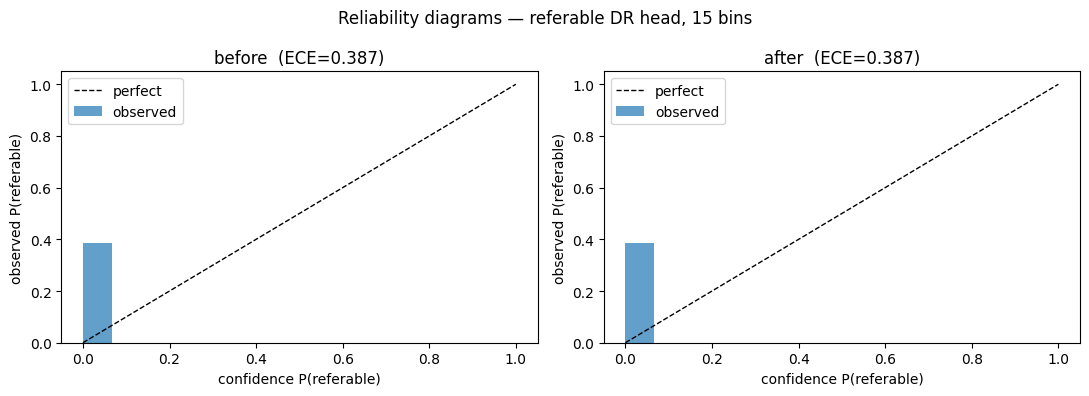

In [4]:
import matplotlib.pyplot as plt

edges = np.linspace(0, 1, 16)
centers = (edges[:-1] + edges[1:]) / 2


def reliability(conf: np.ndarray, correct: np.ndarray) -> np.ndarray:
    """Per-bin observed accuracy for the reliability diagram."""
    out = np.full(len(centers), np.nan)
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        m = (conf >= lo) & (conf <= hi) if lo == 0 else (conf > lo) & (conf <= hi)
        if m.any():
            out[i] = correct[m].mean()
    return out


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, conf, title in ((axes[0], ref_raw, "before"), (axes[1], ref_cal, "after")):
    ax.bar(
        centers, reliability(conf, y_bin.astype(float)), width=1 / 15, alpha=0.7, label="observed"
    )
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
    ax.set_title(f"{title}  (ECE={ece_binary(conf, y_bin):.3f})")
    ax.set_xlabel("confidence P(referable)")
    ax.set_ylabel("observed P(referable)")
    ax.legend()
fig.suptitle("Reliability diagrams — referable DR head, 15 bins")
fig.tight_layout()
plt.show()

## 3 · Export — the contract graph

```
input : float32 (1, 3, H, W) ImageNet-normalised
output: float32 (1, 5) grade probabilities (rows sum to 1)
```

`InferenceWrapper` folds backbone → ordinal head → **calibration temperature** →
`ordinal_probs` into one graph, so the exported probs are already calibrated and consumers
never see the 4 logits. `torch.onnx.export` here mirrors what
`python -m retinaedge.export.export_onnx` does in production (opset 17, dynamic batch).

*Toolchain note:* we pass `dynamo=False` (TorchScript exporter). The new dynamo exporter
(torch ≥ 2.14) emits opset-18 graphs that onnxruntime's dynamic quantizer cannot yet
shape-infer, and its opset-17 down-conversion is lossy — the legacy exporter produces
clean opset-17 graphs that onnxruntime, onnx2tf and ai-edge-torch all handle.

In [5]:
class InferenceWrapper(nn.Module):
    """Contract export graph: (B,3,H,W) -> (B,5) calibrated grade probabilities."""

    def __init__(self, net: nn.Module, temp: float) -> None:
        super().__init__()
        self.net = net
        self.register_buffer("temperature", torch.tensor(float(temp)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return ordinal_probs(self.net(x)["ordinal_logits"] / self.temperature)


wrapper = InferenceWrapper(model, temperature).eval()
onnx_path = ART / "02_model.onnx"
torch.onnx.export(
    wrapper,
    torch.zeros(1, 3, IMG_SIZE, IMG_SIZE),
    str(onnx_path),
    opset_version=17,
    dynamo=False,  # legacy TorchScript exporter: opset-17 graph the ORT quantizer understands
    input_names=["image"],
    output_names=["probs"],
    dynamic_axes={"image": {0: "batch"}, "probs": {0: "batch"}},
)
print(f"exported {onnx_path.name}: {onnx_path.stat().st_size / 1e6:.2f} MB")

/tmp/ipykernel_6528/1286824454.py:15: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


exported 02_model.onnx: 6.10 MB


## 4 · Runtime parity, latency, int8 preview

Production rule (`docs/EXPORT_DEPLOY.md`): the exporter **fails loudly** if onnxruntime
disagrees with PyTorch by more than `atol 1e-3`. We do the same check by hand, benchmark a
few dozen single-image runs, and preview dynamic int8 quantization (the *real* edge path is
full-integer TFLite with a representative dataset — see the doc).

In [6]:
import onnxruntime as ort

sess = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
in_name = sess.get_inputs()[0].name
print("ORT input:", sess.get_inputs()[0].shape, "-> output:", sess.get_outputs()[0].shape)

with torch.no_grad():
    torch_probs = wrapper(torch.from_numpy(x_va[:32])).numpy()
ort_probs = sess.run(None, {in_name: x_va[:32]})[0]
max_err = float(np.abs(torch_probs - ort_probs).max())
print(f"parity max abs err: {max_err:.2e}  ({'PASS' if max_err < 1e-3 else 'FAIL'}, atol 1e-3)")
assert max_err < 1e-3

single = x_va[:1]
for _ in range(5):  # warmup
    sess.run(None, {in_name: single})
t0 = time.perf_counter()
for _ in range(50):
    sess.run(None, {in_name: single})
dt = (time.perf_counter() - t0) / 50
print(f"ORT float32 latency: {dt * 1e3:.2f} ms/image (mean over 50)")

ORT input: ['batch', 3, 64, 64] -> output: ['batch', 'Divprobs_dim_1']


parity max abs err: 1.79e-07  (PASS, atol 1e-3)


ORT float32 latency: 2.19 ms/image (mean over 50)


In [7]:
from onnxruntime.quantization import QuantType, quantize_dynamic

int8_path = ART / "02_model.int8.onnx"
quantize_dynamic(str(onnx_path), str(int8_path), weight_type=QuantType.QInt8)
sess8 = ort.InferenceSession(str(int8_path), providers=["CPUExecutionProvider"])
q_probs = sess8.run(None, {sess8.get_inputs()[0].name: x_va[:32]})[0]
q_err = float(np.abs(torch_probs - q_probs).max())
q_agree = float((q_probs.argmax(1) == torch_probs.argmax(1)).mean())
for _ in range(5):
    sess8.run(None, {sess8.get_inputs()[0].name: single})
t0 = time.perf_counter()
for _ in range(50):
    sess8.run(None, {sess8.get_inputs()[0].name: single})
dt8 = (time.perf_counter() - t0) / 50
print(
    f"size      : {onnx_path.stat().st_size / 1e6:.2f} MB -> "
    f"{int8_path.stat().st_size / 1e6:.2f} MB"
)
print(f"parity    : max abs err {q_err:.2e} (int8 is lossy — expect > float32)")
print(f"argmax agreement vs float32: {q_agree:.1%}")
print(f"latency   : {dt * 1e3:.2f} ms -> {dt8 * 1e3:.2f} ms (dynamic int8, CPU)")

size      : 6.10 MB -> 1.71 MB
parity    : max abs err 8.87e-04 (int8 is lossy — expect > float32)
argmax agreement vs float32: 100.0%
latency   : 2.19 ms -> 12.42 ms (dynamic int8, CPU)


## 5 · Wrap-up

| Notebook step | Production equivalent |
|---|---|
| manual temperature fit (LBFGS) | `python -m retinaedge.eval.calibration --ckpt best.pt --out temperature.json` |
| `torch.onnx.export` + manual parity | `python -m retinaedge.export.export_onnx --ckpt best.pt` (auto parity + size/latency report) |
| dynamic int8 ONNX preview | `export_tflite --direct --int8` with a **representative dataset** → full-integer TFLite for Android |
| — | `retinaedge.export.metadata` → `labels.txt` + `model_info.json` for `com.retinaedge.app` |

The temperature fitted here is baked into the export graph — exactly the contract's rule
that consumers never rescale probabilities. On Android: `grade = argmax(probs)`,
`referable = probs[2] + probs[3] + probs[4] >= 0.5`.

**Artifacts** (gitignored): `artifacts/notebooks/02_model.onnx`, `02_model.int8.onnx`.

> ⚠️ Research/educational — not a medical device. Synthetic-data metrics carry no clinical
> meaning.